In [10]:
from dotenv import load_dotenv
import os
load_dotenv()
if os.environ["GOOGLE_API_KEY"]=="" :
    raise ValueError("Please set the GOOGLE_API_KEY environment variable in the .env file.")
else:
    print("GOOGLE_API_KEY is set.")

GOOGLE_API_KEY is set.


In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # or "gemini-1.0-pro", "gemini-2.0-flash", etc.
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

llm



ChatGoogleGenerativeAI(output_version=None, profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=1.0, max_retries=2, client=<google.genai.client.Client object at 0x0000022618F01090>, default_metadata=(), model_kwargs={})

## **Pydantic Schema**

In [12]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="The topic of the conversation")
    post: str = Field(description="The post content")
    curated_post: str = Field(description="The curated post content ")

demo_obj = graph_schema(topic="The importance of data privacy in digital age", 
                        post="Data Privacy is crucial in today's digital world. WIth the increasing use of technology, protecting personal information has become more important than ever.", 
                        curated_post="In the digital age, data privacy is of utmost importance. With the proliferation of technology, safeguarding personal information has become a critical concern for individuals and organizations alike."
                        )

print(demo_obj)

topic='The importance of data privacy in digital age' post="Data Privacy is crucial in today's digital world. WIth the increasing use of technology, protecting personal information has become more important than ever." curated_post='In the digital age, data privacy is of utmost importance. With the proliferation of technology, safeguarding personal information has become a critical concern for individuals and organizations alike.'


In [13]:
def create_post(state:graph_schema)-> graph_schema:
    topic = state.topic
    post = llm.invoke(f"Curate the following post on the topic '{topic}'").content
    state.post = post
    return state

def curate_post(state:graph_schema)-> graph_schema:
    post = state.post
    curated_post = llm.invoke(f"Curate the following post with GenZ tone: '{post}'").content
    state.curated_post = curated_post
    return state

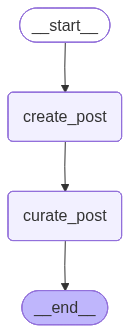

In [14]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)
#Adding nodes
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)
#Adding edges
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()

from IPython.display import Image, display
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [16]:
pydantic_graph.invoke(graph_schema(topic="The importance of data privacy in digital age", 
                                  post="",curated_post=""))

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 40.434085632s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT